## 1. Предварительная проверка данных

Перед тем как отвечать на исследовательские вопросы, важно сначала понять, что именно содержится в данных. Все найденные проблемы будут учтены на этапе очистки данных и напрямую повлияют на правила обработки в следующем разделе (2).

**Об источнике данных.** Оба файла построены на основе open-source базы LiteLLM model price & context window database из репозитория BerriAI LiteLLM GitHub repository. База содержит информацию о ценах на AI-модели, размерах контекстного окна и других характеристиках моделей, поддерживаемых различными LLM-провайдерами.

Для восстановления динамики изменения цен использовалась полная история изменений Git-репозитория, на основе которой были построены еженедельные снимки (weekly snapshots). Данные актуальны на 29 сентября 2026 года.

Исходные данные были дополнительно обработаны и расширены автором датасета Abiram Bharathi S.A.

**Основные особенности данных**:
- **Цены представлены как публичные list prices в USD** для стандартного использования API. Они не включают индивидуальные корпоративные скидки, специальные тарифы /тарифы для больших объёмов потребления
-  Поле `first_listed_week` отражает дату появления модели в базе данных, а не официальную дату релиза модели. Обычно эти события происходят близко друг к другу, но возможна задержка между запуском API и добавлением записи в базу
- Изменения цен в истории могут отражать не только реальные изменения стоимости API, но и **исправления ранее внесенных ошибок** в исходных данных
- Информация о разработчике модели и стране происхождения была определена с помощью правил сопоставления названий. Для части моделей источник не позволяет однозначно определить эти параметры; такие записи относятся к категории "Other"
- Одна и та же модель может встречаться несколько раз, если она доступна через разных провайдеров, регионы или варианты размещения API. Такие записи сохраняются намеренно, поскольку стоимость и условия использования могут различаться


**Лицензирование**

Исходные данные LiteLLM предоставлены проектом Berri AI и распространяются под лицензией MIT License (Copyright © 2023 Berri AI). Производный датасет также распространяется в соответствии с условиями MIT License.

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Settings used throughout the notebook
TEXT_MODES = ["chat", "responses"]
INPUT_WEIGHT = 0.75        # blended price = 75% input + 25% output (3:1 convention)
CORRECTION_RATIO = 10      # a one-step change of 10x or more = data correction
BULK_MIN_CHANGES = 5       # 5+ changes by one provider in one week = batch week

### 1.1 Обзор

In [3]:
hist_raw = pd.read_csv("/workspaces/ai-model-pricing-analysis-/data/ai_model_price_history.csv", parse_dates=["week_start"])
snap_raw = pd.read_csv("/workspaces/ai-model-pricing-analysis-/data/ai_models_2026.csv", parse_dates=["first_listed_week"])

In [5]:
print("Snapshot (ai_models_2026):", snap_raw.shape[0], "rows x", snap_raw.shape[1], "columns")
print("Price history (ai_model_price_history):", hist_raw.shape[0], "rows x", hist_raw.shape[1], "columns")
print()
print("History covers", hist_raw["week_start"].nunique(), "weeks:",
      hist_raw["week_start"].min().date(), "to", hist_raw["week_start"].max().date())

Snapshot (ai_models_2026): 4403 rows x 31 columns
Price history (ai_model_price_history): 167787 rows x 9 columns

History covers 157 weeks: 2023-09-18 to 2026-09-28


In [10]:
snap_raw.head(3).T

,0,1,2
model_id,fireworks_ai/accounts/fireworks/models/llava-y...,fireworks_ai/accounts/fireworks/models/yi-34b,fireworks_ai/accounts/fireworks/models/yi-34b-...
model_name,llava-yi-34b,yi-34b,yi-34b-200k-capybara
developer,01.AI,01.AI,01.AI
developer_country,China,China,China
provider,fireworks_ai,fireworks_ai,fireworks_ai
mode,chat,chat,chat
input_price_per_1m_tokens,0.9,0.9,0.9
output_price_per_1m_tokens,0.9,0.9,0.9
cached_input_price_per_1m_tokens,NaN,NaN,NaN
batch_input_price_per_1m_tokens,NaN,NaN,NaN


In [7]:
hist_raw.head(3)

,week_start,model_id,model_name,developer,provider,mode,input_price_per_1m_tokens,output_price_per_1m_tokens,max_input_tokens
0,2024-09-23,accounts/fireworks/models/llama-v3p2-90b-visio...,llama-v3p2-90b-vision-instruct,Meta,fireworks_ai,chat,0.9,0.9,16384.0
1,2024-09-30,accounts/fireworks/models/llama-v3p2-90b-visio...,llama-v3p2-90b-vision-instruct,Meta,fireworks_ai,chat,0.9,0.9,16384.0
2,2024-10-07,accounts/fireworks/models/llama-v3p2-90b-visio...,llama-v3p2-90b-vision-instruct,Meta,fireworks_ai,chat,0.9,0.9,16384.0


**Что означает одна строка в файле?**
- Snapshot: одна строка представляет собой одну комбинацию «модель × провайдер» на текущий момент. Например, модель DeepSeek-R1, доступная через провайдера Fireworks
- History: одна строка представляет собой одну комбинацию «модель × провайдер × неделя наблюдения». Ниже мы проверим, что для каждой такой комбинации существует только одна запись на каждую неделю

In [11]:
print("Duplicate model_id in snapshot:", snap_raw["model_id"].duplicated().sum())
print("Duplicate (model_id, week) in history: ", hist_raw.duplicated(["model_id", "week_start"]).sum())

Duplicate model_id in snapshot: 0
Duplicate (model_id, week) in history:  0


### 1.2 Словарь по типам колонок в данных

In [12]:
dictionary = pd.DataFrame({
    "type": snap_raw.dtypes.astype(str),
    "missing_%": (snap_raw.isna().mean() * 100).round(1),
    "unique_values": snap_raw.nunique(),
    "example": snap_raw.iloc[0],
})
dictionary

,type,missing_%,unique_values,example
model_id,str,0.0,4403,fireworks_ai/accounts/fireworks/models/llava-y...
model_name,str,0.0,2265,llava-yi-34b
developer,str,0.0,51,01.AI
developer_country,str,0.0,12,China
provider,str,0.0,133,fireworks_ai
mode,str,0.0,14,chat
input_price_per_1m_tokens,float64,17.1,328,0.9
output_price_per_1m_tokens,float64,17.4,392,0.9
cached_input_price_per_1m_tokens,float64,62.1,214,NaN
batch_input_price_per_1m_tokens,float64,91.7,55,NaN


### 1.3 Пропущенные значения

Пропуски в ценовых полях являются ожидаемыми для тех параметров, которые применимы только к определенным типам моделей. Например, ожидается, что колонка `price_per_image` будет заполнена только для моделей, работающих с изображениями, и будет отсутствовать для текстовых моделей

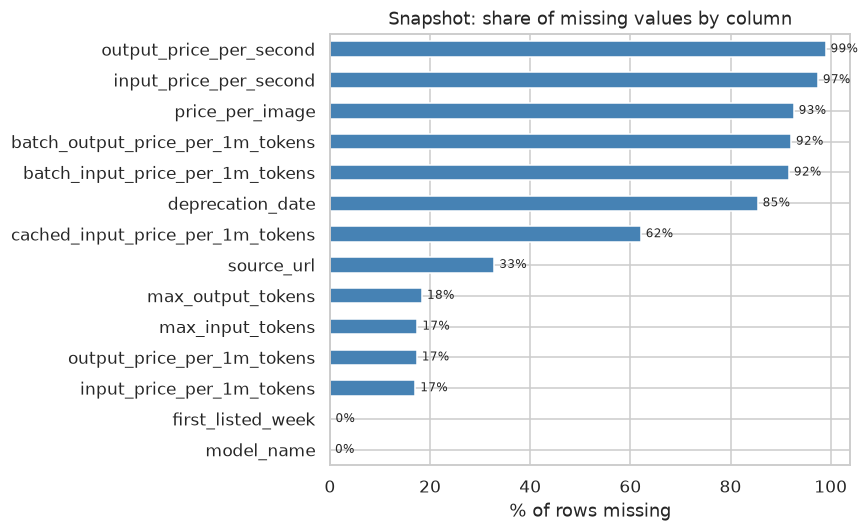

In [13]:
missing = (snap_raw.isna().mean() * 100).sort_values()
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 5))
missing.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% of rows missing")
ax.set_title("Snapshot: share of missing values by column")
for i, v in enumerate(missing):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# Характерны ли пропуски данных для НЕ текстовых моделей?
price_by_mode = snap_raw.groupby("mode").agg(
    listings=("model_id", "size"),
    share_with_token_price=("input_price_per_1m_tokens", lambda s: s.notna().mean()),
)
price_by_mode.round(2).sort_values("listings", ascending=False)

,listings,share_with_token_price
mode,,
chat,3340,0.96
image_generation,405,0.14
embedding,148,0.94
responses,143,0.84
audio_transcription,93,0.15
realtime,51,0.92
video_generation,45,0.00
audio_speech,40,0.38
completion,34,0.97


**Анализ пропущенных значений**

- **Цены за токены и размер контекстного окна (около 17% пропусков в целом, около 5% среди текстовых моделей).**  
  Модели для работы с изображениями, видео и аудио, как правило, тарифицируются по количеству изображений или времени использования (например, за секунду), поэтому поля с ценами за токены для них отсутствуют по определению.  Среди текстовых моделей около 5% записей не имеют указанной цены, а ещё примерно 3% содержат значение `$0`, используемое как placeholder. Таким образом, около **92% текстовых моделей пригодны для анализа стоимости**.

- **Цены за кешированные токены и batch-обработку (62% и 92% пропусков соответственно).**  
  Эти параметры представляют собой дополнительные скидочные механизмы. Пустое значение может означать как отсутствие такой опции у провайдера, так и то, что информация не была внесена в базу. Полнота данных сильно различается между провайдерами.  
  В рамках данного анализа эти поля **не используются**.

- **Цены за изображение и секунду использования (93–99% пропусков).**  
  Эти параметры применимы только к моделям, работающим с изображениями, видео и аудио. Высокая доля пропусков является ожидаемой и не считается проблемой качества данных.

- **`deprecation_date` (85% пропусков).**  
  Пустое значение означает, что дата вывода модели из эксплуатации не была объявлена. Это является нормальной ситуацией для большинства активных моделей.

- **`source_url` (33% пропусков).**  
  Это вспомогательное поле, содержащее ссылки на документацию. Оно используется только для справочных целей и не влияет на результаты анализа.

- **Флаги возможностей модели (0% пропусков, но потенциально вводящие в заблуждение).**  
  Несмотря на отсутствие пропущенных значений, эти поля требуют осторожной интерпретации. Значение `False` часто означает не то, что функция действительно не поддерживается моделью, а то, что информация о ней не была заполнена в базе данных.  
  Это является **одной из наиболее существенных скрытых проблем качества данных**.
  



  ### 3.4 Какие типы моделей есть в данных?

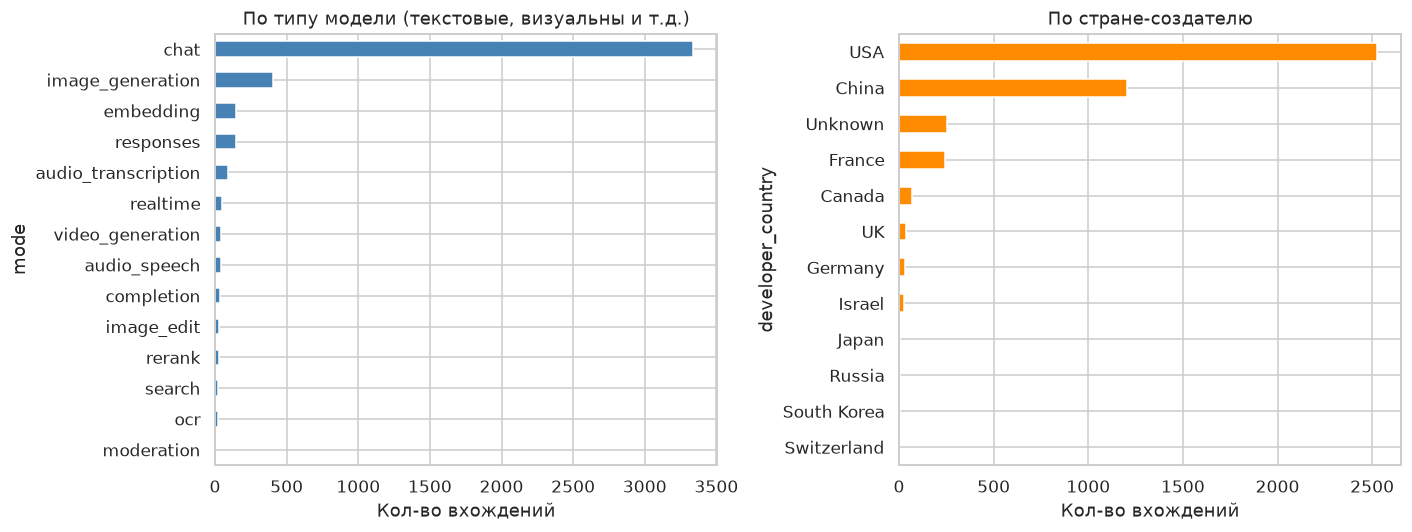

Текстовые модели (chat + responses): 79% всего датасета


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

snap_raw["mode"].value_counts().plot.barh(ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("По типу модели (текстовые, визуальны и т.д.)")
axes[0].set_xlabel("Кол-во вхождений")

snap_raw["developer_country"].value_counts().plot.barh(ax=axes[1], color="darkorange")
axes[1].invert_yaxis()
axes[1].set_title("По стране-создателю")
axes[1].set_xlabel("Кол-во вхождений")

plt.tight_layout()
plt.show()

text_share = snap_raw["mode"].isin(TEXT_MODES).mean()
print(f"Текстовые модели (chat + responses): {text_share:.0%} всего датасета")

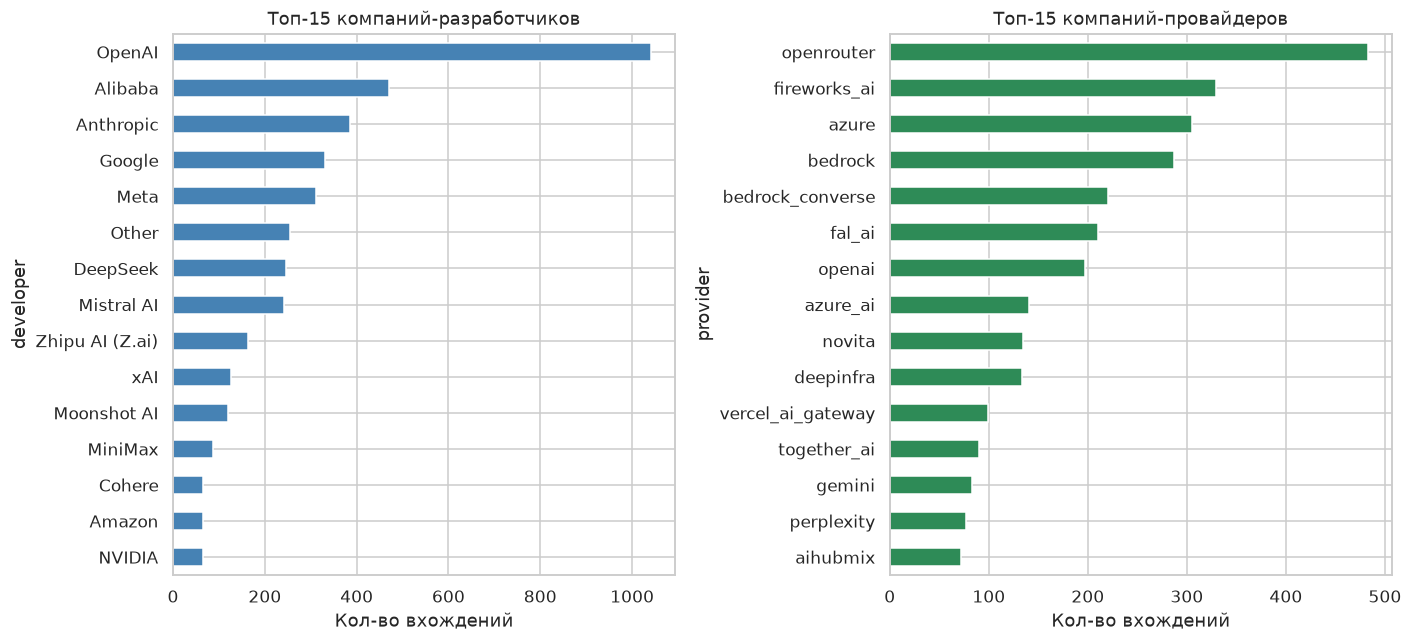

Компании-разрабочики: 51 | Компании-провайдеры: 133
Кол-во строк с не указанной компанией-разработчиком ('Other'): 5.8%


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_dev = snap_raw["developer"].value_counts().head(15)
top_dev.plot.barh(ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Топ-15 компаний-разработчиков")
axes[0].set_xlabel("Кол-во вхождений")

top_prov = snap_raw["provider"].value_counts().head(15)
top_prov.plot.barh(ax=axes[1], color="seagreen")
axes[1].invert_yaxis()
axes[1].set_title("Топ-15 компаний-провайдеров")
axes[1].set_xlabel("Кол-во вхождений")

plt.tight_layout()
plt.show()

print("Компании-разрабочики:", snap_raw["developer"].nunique(), "| Компании-провайдеры:", snap_raw["provider"].nunique())
print("Кол-во строк с не указанной компанией-разработчиком ('Other'):", f"{(snap_raw['developer'] == 'Other').mean():.1%}")

### 1.5 Цены токенов

Начиная с этого этапа, анализ будет сосредоточен на **текстовых моделях**, поскольку исследовательские вопросы связаны с динамикой цен за токены.

Цены на AI-модели могут значительно отличаться, поэтому для визуализации используется логарифмическая шкала. Она позволяет корректно отображать как бюджетные, так и наиболее дорогие модели на одном графике и лучше сравнивать распределение цен.

In [21]:
text = snap_raw[snap_raw["mode"].isin(TEXT_MODES)].copy()

print("Всего строк для текстовых моделей:", len(text))
print("Строки с нулевой ценой (=$0): ", (text["input_price_per_1m_tokens"] == 0).sum())
print("Строки с пропущеной ценой:", text["input_price_per_1m_tokens"].isna().sum())

text[["input_price_per_1m_tokens", "output_price_per_1m_tokens"]].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
).round(2)

Всего строк для текстовых моделей: 3483
Строки с нулевой ценой (=$0):  107
Строки с пропущеной ценой: 167


,input_price_per_1m_tokens,output_price_per_1m_tokens
count,3316.00,3320.00
mean,1.96,8.77
std,6.09,27.00
min,0.00,0.00
10%,0.07,0.18
25%,0.18,0.50
50%,0.60,1.80
75%,1.96,7.51
90%,4.00,20.00
max,150.00,600.00


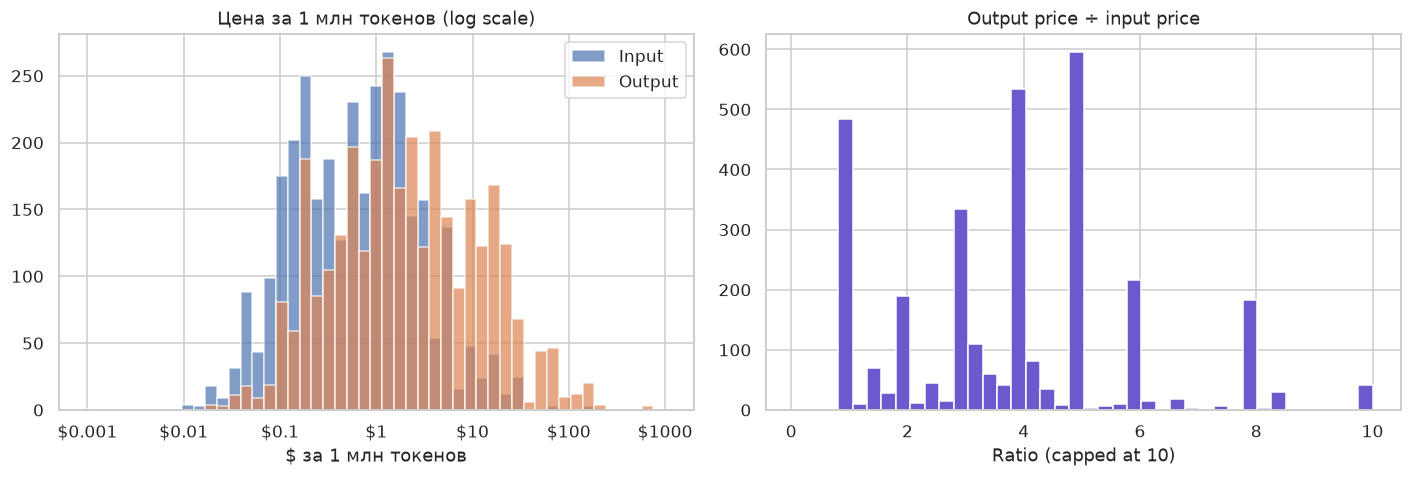

Медианное соотношение output/input цен: 4.0
Доля строк, где output цена = input цене: 15%


In [23]:
priced = text[(text["input_price_per_1m_tokens"] > 0) & (text["output_price_per_1m_tokens"] > 0)].copy()
bins = np.logspace(-3, 3, 50)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(priced["input_price_per_1m_tokens"], bins=bins, alpha=0.7, label="Input")
axes[0].hist(priced["output_price_per_1m_tokens"], bins=bins, alpha=0.7, label="Output")
axes[0].set_xscale("log")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:g}"))
axes[0].set_title("Цена за 1 млн токенов (log scale)")
axes[0].set_xlabel("$ за 1 млн токенов")
axes[0].legend()

priced["out_in_ratio"] = priced["output_price_per_1m_tokens"] / priced["input_price_per_1m_tokens"]
axes[1].hist(priced["out_in_ratio"].clip(upper=10), bins=40, color="slateblue")
axes[1].set_title("Output price ÷ input price")
axes[1].set_xlabel("Ratio (capped at 10)")

plt.tight_layout()
plt.show()

print("Медианное соотношение output/input цен:", priced["out_in_ratio"].median().round(1))
print("Доля строк, где output цена = input цене:", f"{(priced['out_in_ratio'] == 1).mean():.0%}")

In [24]:
# Самые дорогие и самые дешевые текстовые модели
cheapest_listing = priced.sort_values("input_price_per_1m_tokens").drop_duplicates(["model_name", "developer"])
cols = ["model_name", "developer", "provider", "input_price_per_1m_tokens", "output_price_per_1m_tokens"]

print("Самые дорогие:")
display(cheapest_listing.nlargest(8, "input_price_per_1m_tokens")[cols])
print("Самые дешевые:")
display(cheapest_listing.nsmallest(8, "input_price_per_1m_tokens")[cols])

Самые дорогие:


,model_name,developer,provider,input_price_per_1m_tokens,output_price_per_1m_tokens
3383,o1-pro,OpenAI,openai,150.0,600.0
3385,o1-pro-2025-03-19,OpenAI,openai,150.0,600.0
2762,gpt-4.5-preview,OpenAI,azure,75.0,150.0
2716,gpt-4-32k-0613,OpenAI,azure,60.0,120.0
2715,gpt-4-32k,OpenAI,azure,60.0,120.0
3058,gpt-5.5-pro-2026-04-23,OpenAI,azure,30.0,180.0
3031,gpt-5.4-pro-2026-03-05,OpenAI,azure_ai,30.0,180.0
2705,gpt-4,OpenAI,azure,30.0,60.0


Самые дешевые:


,model_name,developer,provider,input_price_per_1m_tokens,output_price_per_1m_tokens
978,flux-1-dev-controlnet-union,Black Forest Labs,fireworks_ai,0.0010,0.001
55,Qwen2.5-Coder-7B,Alibaba,nebius,0.0100,0.030
54,Qwen2.5-Coder-3B-Instruct,Alibaba,nscale,0.0100,0.030
56,Qwen2.5-Coder-7B-Instruct,Alibaba,nscale,0.0100,0.030
2594,nemotron-3.5-lightning-30b-a3b,NVIDIA,perplexity,0.0115,0.170
3294,gpt-oss-20b,OpenAI,darkbloom,0.0145,0.070
1992,llama3.2-3b-instruct,Meta,lambda_ai,0.0150,0.025
1989,llama3.2-11b-vision-instruct,Meta,lambda_ai,0.0150,0.025


### 1.6 Контекстное окно

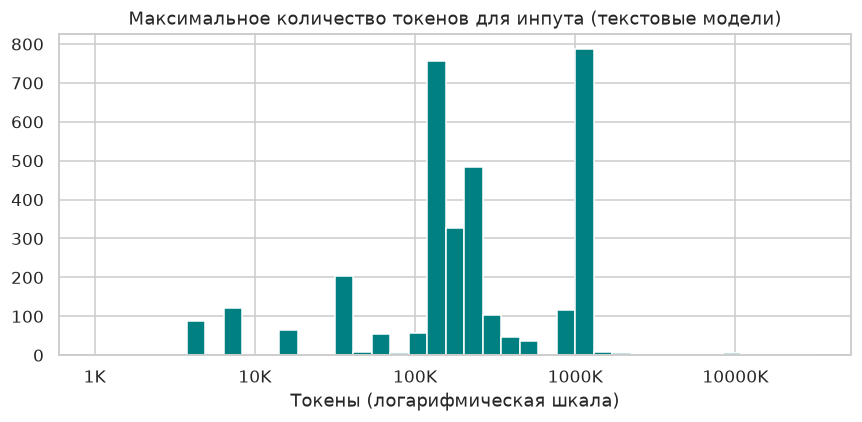

count        3299.0
mean       413485.0
std        556469.0
min           512.0
10%         32000.0
25%        128000.0
50%        200000.0
75%        997952.0
90%       1048576.0
max      10485760.0
Name: max_input_tokens, dtype: float64

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(text["max_input_tokens"].dropna(), bins=np.logspace(3, 7.5, 40), color="teal")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:g}K"))
ax.set_title("Максимальное количество токенов для инпута (текстовые модели)")
ax.set_xlabel("Токены (логарифмическая шкала)")
plt.tight_layout()
plt.show()

text["max_input_tokens"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(0)

### 1.7 Флаги возможностей моделей


В датасете есть 12 булевых (`true/false`) признаков, которые описывают возможности каждой модели.

**Важно:** в этой базе данных значение флага устанавливается пользователем, который добавляет запись о модели. Поэтому значение `False` может означать как:

- функция действительно **не поддерживается моделью**;
- информация об этой возможности **просто не была заполнена**.

Таким образом, эти признаки необходимо интерпретировать с осторожностью, поскольку отсутствие отметки не всегда означает отсутствие функциональности.

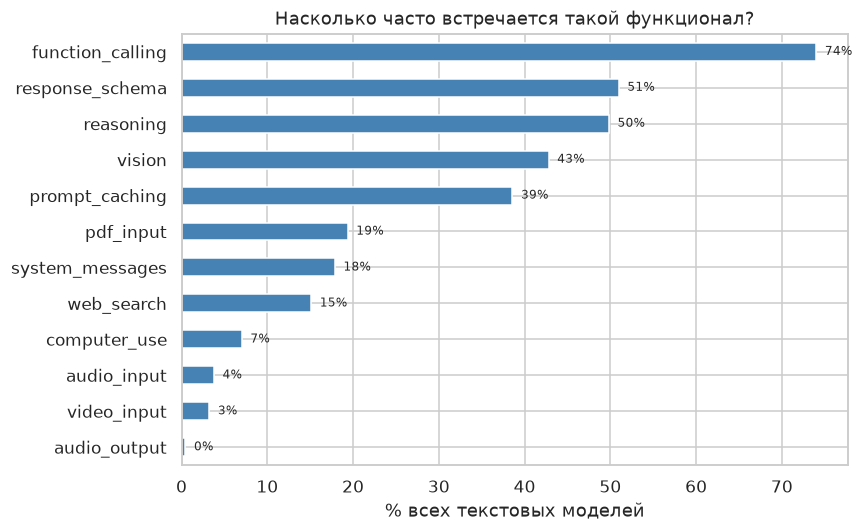

In [29]:
flag_cols = [c for c in snap_raw.columns if c.startswith("supports_")]
flag_share = (text[flag_cols].mean() * 100).sort_values()
flag_share.index = flag_share.index.str.replace("supports_", "")

fig, ax = plt.subplots(figsize=(8, 5))
flag_share.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% всех текстовых моделей")
ax.set_title("Насколько часто встречается такой функционал?")
for i, v in enumerate(flag_share):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

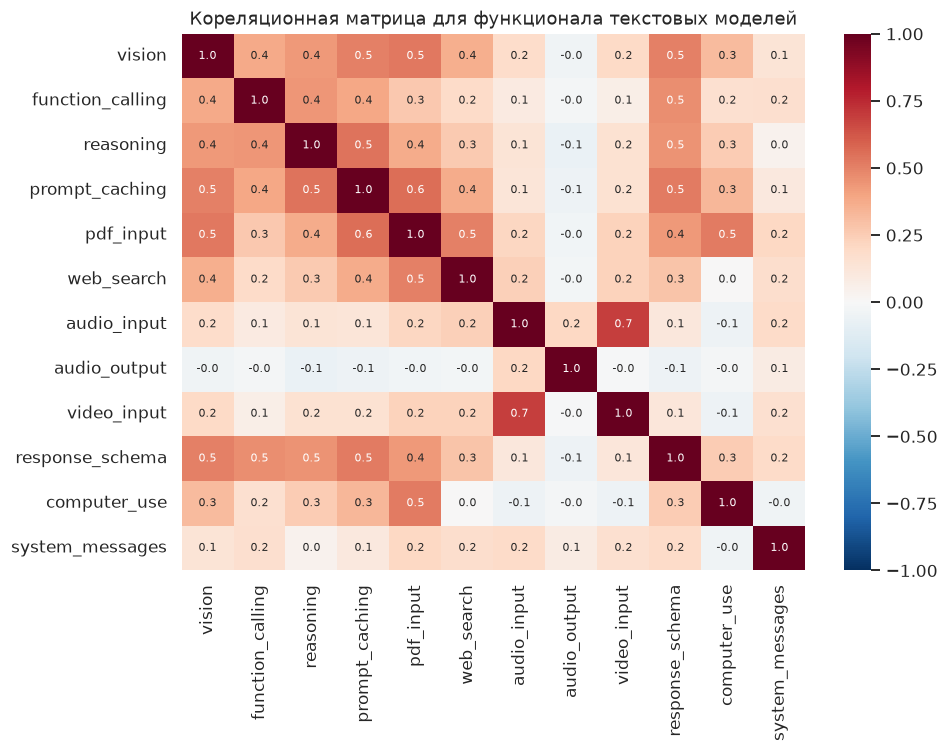

In [30]:
# Какие врзможности чаще встречаются вместе?
corr = text[flag_cols].astype(int).corr()
corr.index = corr.columns = [c.replace("supports_", "") for c in flag_cols]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Кореляционная матрица для функционала текстовых моделей")
plt.tight_layout()
plt.show()

In [32]:
# Одинаково ли размечены возможности моделей у разных провайдеров? На примере модели DeepSeek-R1
example = text[text["model_name"] == "deepseek-r1"]
example[["provider", "input_price_per_1m_tokens", "supports_reasoning", "supports_function_calling", "supports_vision"]]

,provider,input_price_per_1m_tokens,supports_reasoning,supports_function_calling,supports_vision
1218,azure_ai,1.35,False,False,False
1219,deepseek,0.55,True,True,False
1220,fireworks_ai,3.00,False,False,False
1221,novita,4.00,True,True,False
1222,openrouter,0.70,True,True,False
1223,replicate,3.75,True,False,False
1224,snowflake,1.35,True,False,False
1225,vercel_ai_gateway,0.55,False,False,False


DeepSeek-R1 - reasoning-модель по своей архитектуре, однако 3 из 8 провайдеров, через которых она доступна, указывают значение `supports_reasoning = False`.

В рамках этого датасета значение `False` часто означает не отсутствие поддержки функциональности, а то, что информация о ней **не была заполнена**. При этом часть различий может быть реальной: например, провайдер может не включать поддержку вызова функций (`function calling`) для конкретного варианта развертывания модели.

Однако по имеющимся данным невозможно однозначно определить, какой из этих случаев имеет место. Если все провайдеры указывают одинаковое значение (например, `vision = False`), вероятность того, что этот признак корректен, выше.

Одна и та же модель также может иметь существенно разную стоимость в зависимости от провайдера. Например, цена DeepSeek-R1 варьируется от **$0.55 до $4.00 за 1 млн входных токенов** в зависимости от хоста — почти в **7 раз** при использовании одинаковых весов модели.

**Выводы для дальнейшего анализа**

- Сравнение цен на основе отдельных строк с флагами возможностей может частично отражать не реальные различия в стоимости функций моделей, а то, насколько тщательно разные провайдеры заполняют информацию о возможностях (RQ2)

- Поэтому в дальнейшем при аггрегации функций на уровне модели, функционал считается поддерживаемым, если **хотя бы один провайдер указывает его наличие**

- Значительные различия в стоимости одной и той же модели у разных провайдеров становятся основой для дальнейшего исследования ценовой вариативности (RQ5)

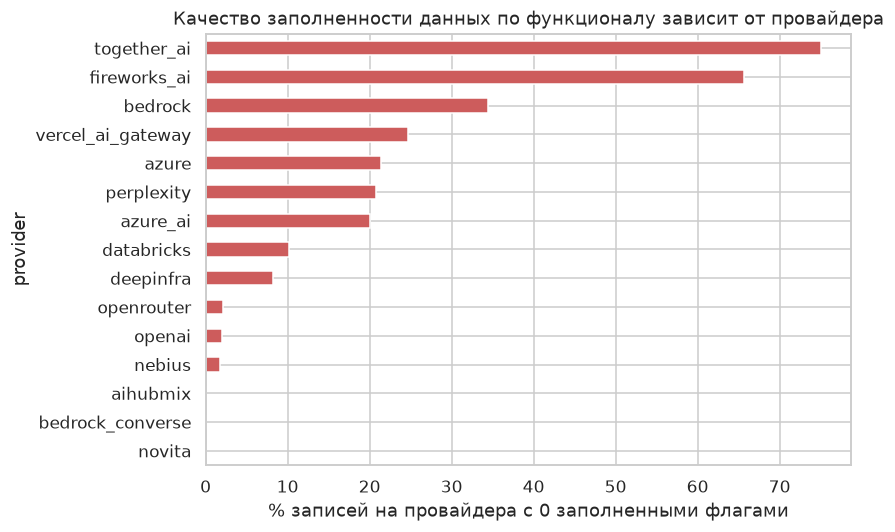

In [33]:
# Доля строк с незаполненными полями по функциональности (топ 15 провайдеров)
text["n_flags"] = text[flag_cols].sum(axis=1)
no_flags = (
    text.groupby("provider")["n_flags"]
    .agg(listings="size", share_no_flags=lambda s: (s == 0).mean())
    .sort_values("listings", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
(no_flags["share_no_flags"] * 100).sort_values().plot.barh(ax=ax, color="indianred")
ax.set_xlabel("% записей на провайдера с 0 заполненными флагами")
ax.set_title("Качество заполненности данных по функционалу зависит от провайдера")
plt.tight_layout()
plt.show()

### 1.8 Одна модель -- множество провайдеров

In [35]:
hosts_per_model = text.groupby(["model_name", "developer"])["provider"].nunique()

print("Model name + developer groups:", len(hosts_per_model))
print("Served by 2+ providers:", (hosts_per_model > 1).sum())
print()
print("Самые популярные у провайдеров модели:")
print(hosts_per_model.sort_values(ascending=False).head(8).to_string())

Model name + developer groups: 1766
Served by 2+ providers: 507

Самые популярные у провайдеров модели:
model_name              developer      
gpt-oss-120b            OpenAI             20
deepseek-v4-flash       DeepSeek           13
gpt-oss-20b             OpenAI             12
deepseek-v4-pro         DeepSeek           10
kimi-k2.7-code          Moonshot AI         9
glm-5.2                 Zhipu AI (Z.ai)     9
deepseek-r1             DeepSeek            8
Llama-3.3-70B-Instruct  Meta                8


In [36]:
# Иногда одна и та же модель может по-разному называться у разных провайдеров. Например, Llama 3.3 70B может называться "llama-3.3-70b", "llama-3.3-70B", "llama-3.3-70B-chat", "llama-3.3-70B-instruct" и т.д.:
llama_names = text.loc[text["model_name"].str.contains("llama.?3.?3.?70b", case=False, regex=True), "model_name"]
print("Spellings of Llama 3.3 70B:", llama_names.nunique())
print(sorted(llama_names.unique()))

Spellings of Llama 3.3 70B: 19
['Llama-3.3-70B-Instruct', 'Llama-3.3-70B-Instruct-Turbo', 'Meta-Llama-3.3-70B-Instruct', 'Meta-Llama-3_3-70B-Instruct', 'databricks-meta-llama-3-3-70b-instruct', 'deepseek-llama3.3-70b', 'dobby-unhinged-llama-3-3-70b-new', 'llama-3-3-70b-instruct', 'llama-3.3-70b', 'llama-3.3-70b-instruct', 'llama-3.3-70b-instruct-fp8-fast', 'llama-3.3-70b-instruct-maas', 'llama3.3-70b', 'llama3.3-70b-instruct', 'llama3.3-70b-instruct-fp8', 'meta.llama-3.3-70b-instruct', 'meta.llama-3.3-70b-instruct-fp8-dynamic', 'meta.llama3-3-70b-instruct-v1:0', 'snowflake-llama-3.3-70b']


In [37]:
# Одна и та же модель может иметь разные цены у разных провайдеров (напримере Deepseek R1)
example_hosts = (
    priced[priced["model_name"] == "deepseek-r1"]
    .sort_values("input_price_per_1m_tokens")
    [["provider", "input_price_per_1m_tokens", "output_price_per_1m_tokens"]]
)
example_hosts

,provider,input_price_per_1m_tokens,output_price_per_1m_tokens
1219,deepseek,0.55,2.19
1225,vercel_ai_gateway,0.55,2.19
1222,openrouter,0.70,2.50
1218,azure_ai,1.35,5.40
1224,snowflake,1.35,5.40
1220,fireworks_ai,3.00,8.00
1223,replicate,3.75,10.00
1221,novita,4.00,4.00


### 1.9 Временное покрытие

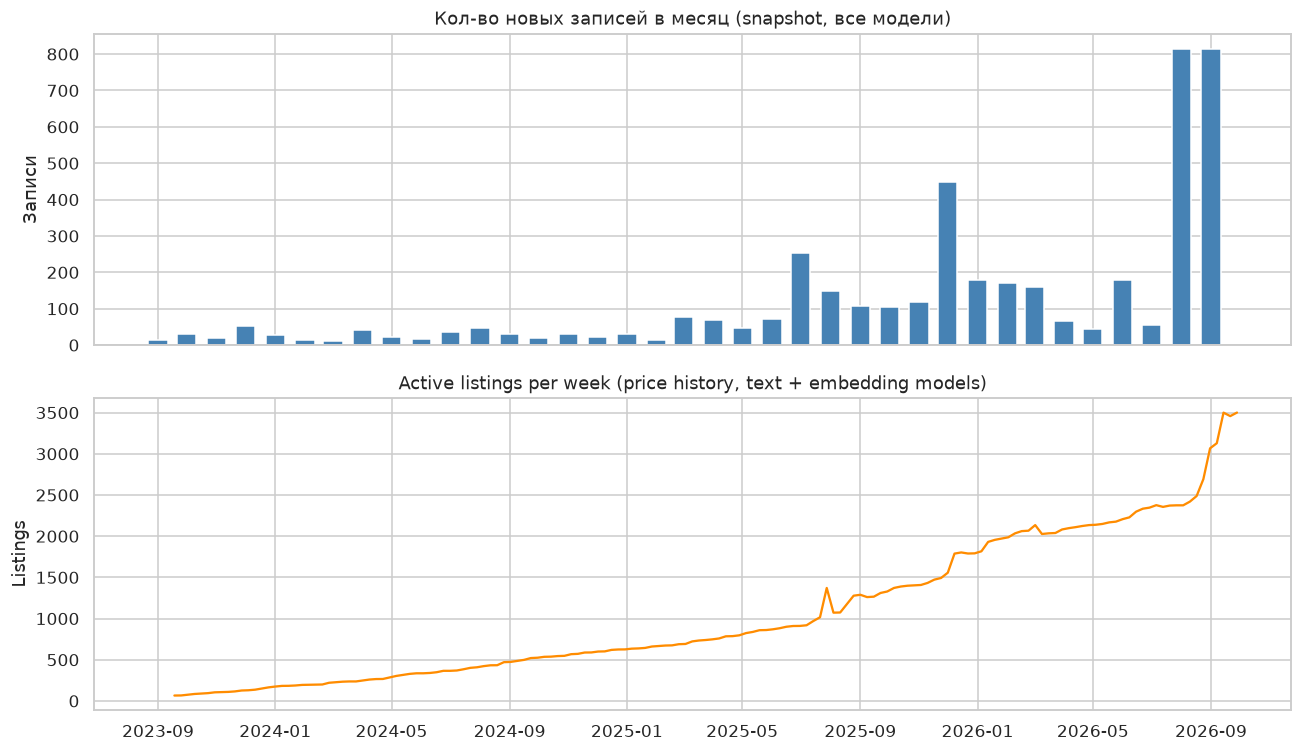

Biggest single weeks of new listings:
first_listed_week
2026-08-31    391
2026-09-14    361
2026-09-21    340
2025-12-08    258
2026-08-24    240


In [38]:
added_per_month = snap_raw.set_index("first_listed_week").resample("MS").size()
active_per_week = hist_raw.groupby("week_start")["model_id"].nunique()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(added_per_month.index, added_per_month.values, width=20, color="steelblue")
axes[0].set_title("Кол-во новых записей в месяц (snapshot, все модели)")
axes[0].set_ylabel("Записи")

axes[1].plot(active_per_week.index, active_per_week.values, color="darkorange")
axes[1].set_title("Active listings per week (price history, text + embedding models)")
axes[1].set_ylabel("Listings")

plt.tight_layout()
plt.show()

print("Biggest single weeks of new listings:")
print(snap_raw["first_listed_week"].value_counts().head(5).to_string())

Резкие скачки на сотни новых записей за одну неделю не означают, что за этот период было выпущено сотни новых моделей. Такие всплески, скорее всего, связаны с добавлением в базу нового провайдера или массовым заполнением ранее отсутствующих данных.

Поэтому для анализа, связанного с датами запуска моделей, будет использоваться дата, когда модель впервые появилась в API своего разработчика, а не дата добавления записи в базу данных.

Кроме того, модели, которые уже присутствовали в базе данных в первую неделю наблюдения, имеют неизвестную фактическую дату запуска. Такие наблюдения цензурированны слева: мы видим модель уже после ее появления, но не знаем, сколько времени прошло с момента реального запуска.

In [40]:
first_seen = hist_raw.groupby("model_id")["week_start"].min()
print("Записи, которое уже пристутсвовали на неделю 1 (дата запуска неизвестна):", (first_seen == hist_raw["week_start"].min()).sum())

# Мэтчатся ли first_listed_week с первой неделей из истории?
check = snap_raw.merge(first_seen.rename("first_in_history"), left_on="model_id", right_index=True)
gap_days = (check["first_listed_week"] - check["first_in_history"]).dt.days
print("first_listed_week равна первой неделе в истории:", f"{(gap_days == 0).mean():.0%} of matched listings")

Записи, которое уже пристутсвовали на неделю 1 (дата запуска неизвестна): 65
first_listed_week равна первой неделе в истории: 99% of matched listings


### 1.10 Как связаны два файла?

In [42]:
snap_ids = set(snap_raw["model_id"])
hist_ids = set(hist_raw["model_id"])

print("Записи, доступные в 2х файлах:     ", len(snap_ids & hist_ids))
print("Есть только в истории (делистинг): ", len(hist_ids - snap_ids))
print("Только в snapshot:           ", len(snap_ids - hist_ids))
print()
print("Модели, представленные только в снэпшоте по типам:")
print(snap_raw[snap_raw["model_id"].isin(snap_ids - hist_ids)]["mode"].value_counts().head(6).to_string())

Записи, доступные в 2х файлах:      3535
Есть только в истории (делистинг):  762
Только в snapshot:            868

Модели, представленные только в снэпшоте по типам:
mode
image_generation       404
chat                   137
audio_transcription     93
video_generation        45
audio_speech            39
image_edit              31


Записи, которые присутствуют только в историческом датасете и отсутствуют в текущем срезе данных, были **удалены из основной базы**. Это, как правило, модели, которые были выведены из использования (`deprecated models`).

Если бы анализ изменения цен проводился только на основе текущего snapshot-файла, мы бы учитывали только модели, которые сохранились на сегодняшний день. В результате анализ был бы смещен в сторону «выживших» моделей и не отражал бы полную динамику рынка.

Поэтому для анализа изменения цен необходимо использовать **исторический файл (`history`)**, который содержит информацию о моделях и их ценах за весь период наблюдения.

### 1.11 Изменения цен в истории

In [45]:
h = hist_raw[hist_raw["mode"].isin(TEXT_MODES)].sort_values(["model_id", "week_start"]).copy()
h["prev_in"] = h.groupby("model_id")["input_price_per_1m_tokens"].shift(1)

changes = h[h["prev_in"].notna() & (h["input_price_per_1m_tokens"] != h["prev_in"])].copy()
changes["direction"] = np.where(changes["input_price_per_1m_tokens"] < changes["prev_in"], "сокращение", "рост")

print("Изменения цен инпут-токенов за 3 года:", len(changes))
print(changes["direction"].value_counts().to_string())
print()
print("Строки с ценой $0:", (h["input_price_per_1m_tokens"] == 0).sum(),
      "across", h.loc[h["input_price_per_1m_tokens"] == 0, "model_id"].nunique(), "listings")

Изменения цен инпут-токенов за 3 года: 614
direction
сокращение    338
рост          276

Строки с ценой $0: 7325 across 217 listings


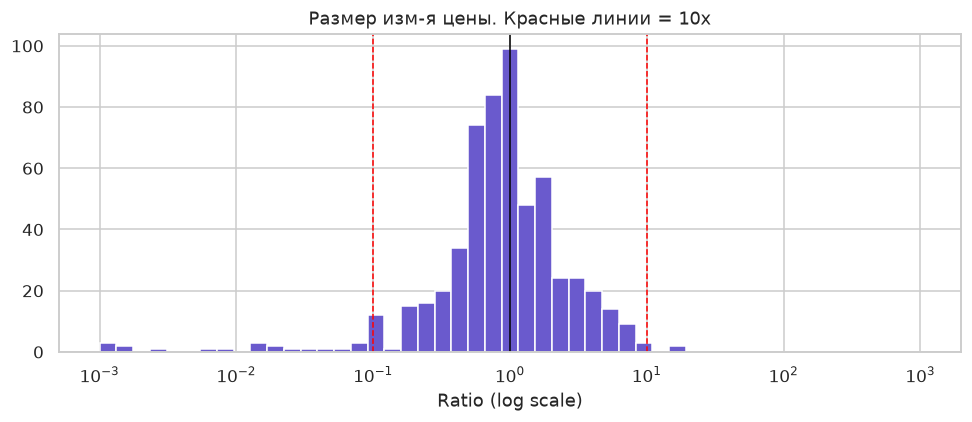

Изменения в 10x и больше: 39


In [47]:
# Насколько это большие изменения? (ratio = новая цена / старая цена)
valid = changes[(changes["prev_in"] > 0) & (changes["input_price_per_1m_tokens"] > 0)].copy()
valid["ratio"] = valid["input_price_per_1m_tokens"] / valid["prev_in"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(valid["ratio"], bins=np.logspace(-3, 3, 50), color="slateblue")
ax.set_xscale("log")
ax.axvline(1, color="black", lw=1)
ax.axvline(CORRECTION_RATIO, color="red", ls="--", lw=1)
ax.axvline(1 / CORRECTION_RATIO, color="red", ls="--", lw=1)
ax.set_title("Размер изм-я цены. Красные линии = 10x")
ax.set_xlabel("Ratio (log scale)")
plt.tight_layout()
plt.show()

print("Изменения в 10x и больше:", ((valid["ratio"] >= 10) | (valid["ratio"] <= 0.1)).sum())

In [48]:
# Примеры изменений цен, которые, вероятно, являются исправлениями, а не реальными сдвигами в прайсинге
valid[(valid["ratio"] >= 10) | (valid["ratio"] <= 0.1)].sort_values("week_start")[
    ["week_start", "model_id", "provider", "prev_in", "input_price_per_1m_tokens"]
].head(12)

,week_start,model_id,provider,prev_in,input_price_per_1m_tokens
36493,2023-11-20,claude-instant-1.2,anthropic,1.63,0.163000
34837,2024-02-12,chatdolphin,nlp_cloud,20.00,0.500000
155136,2024-05-27,vertex_ai/claude-3-opus@20240229,vertex_ai-anthropic_models,1.50,15.000000
74184,2024-07-01,gemini/gemini-1.5-pro,gemini,0.35,3.500000
74600,2024-07-01,gemini/gemini-1.5-pro-latest,gemini,0.35,3.500000
41444,2024-09-09,command-light,cohere_chat,15.00,0.300000
70221,2024-10-07,gemini-1.5-flash-exp-0827,vertex_ai-language-models,0.50,0.004688
70697,2024-10-07,gemini-1.5-pro-preview-0215,vertex_ai-language-models,5.00,0.078125
70797,2024-10-07,gemini-1.5-pro-preview-0409,vertex_ai-language-models,5.00,0.078125
70892,2024-10-07,gemini-1.5-pro-preview-0514,vertex_ai-language-models,5.00,0.078125


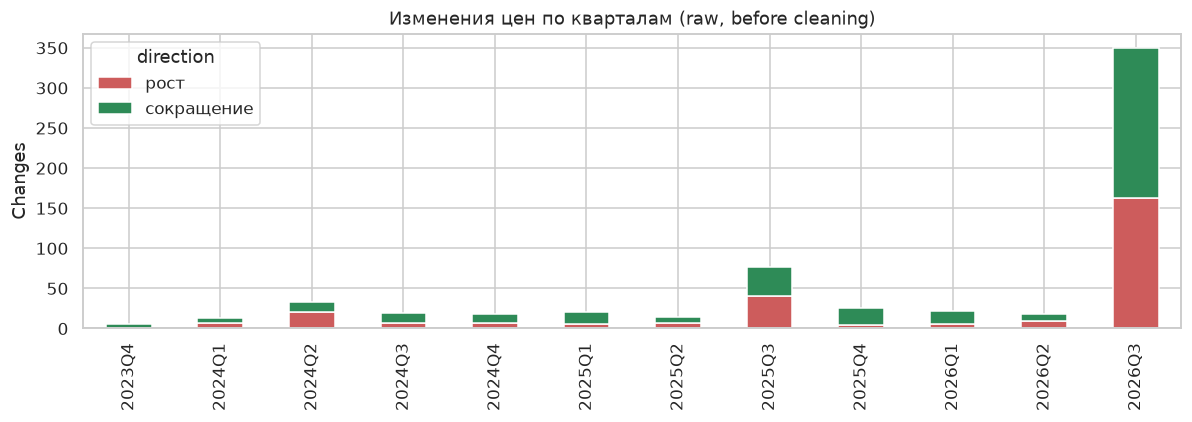

Доля всех изменений в 2026Q3: 57%


In [49]:
# Price changes per quarter
changes["quarter"] = changes["week_start"].dt.to_period("Q").astype(str)
per_quarter = changes.groupby(["quarter", "direction"]).size().unstack(fill_value=0)

ax = per_quarter.plot.bar(stacked=True, figsize=(11, 4), color={"сокращение": "seagreen", "рост": "indianred"})
ax.set_title("Изменения цен по кварталам (raw, before cleaning)")
ax.set_xlabel("")
ax.set_ylabel("Changes")
plt.tight_layout()
plt.show()

last_q = per_quarter.index.max()
print(f"Доля всех изменений в {last_q}: {per_quarter.loc[last_q].sum() / per_quarter.values.sum():.0%}")

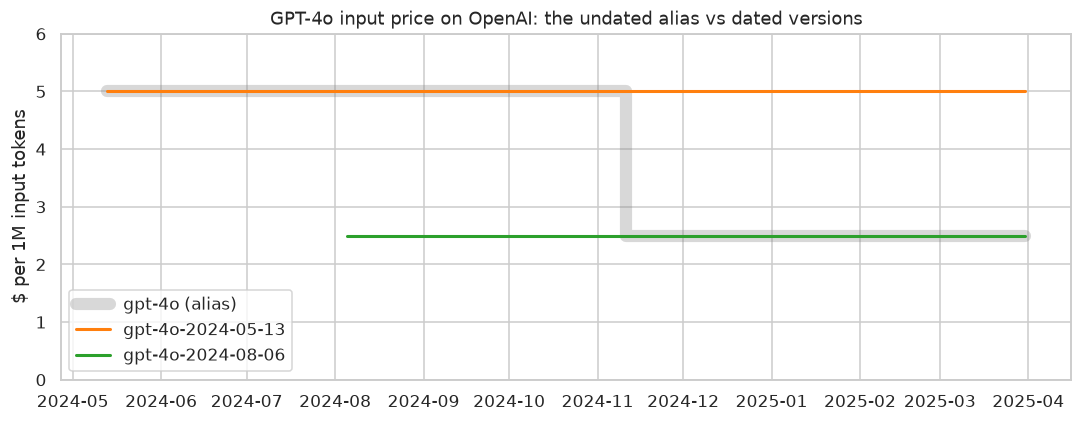

In [50]:
# The GPT-4o "price cut"
gpt4o = h[(h["provider"] == "openai") & h["model_name"].isin(["gpt-4o", "gpt-4o-2024-05-13", "gpt-4o-2024-08-06"])]
gpt4o_wide = gpt4o.pivot(index="week_start", columns="model_name", values="input_price_per_1m_tokens")

gpt4o_wide = gpt4o_wide.loc["2024-05":"2025-03"]

fig, ax = plt.subplots(figsize=(10, 4))

ax.step(gpt4o_wide.index, gpt4o_wide["gpt-4o"], where="post", lw=8, alpha=0.3, color="grey", label="gpt-4o (alias)")
ax.step(gpt4o_wide.index, gpt4o_wide["gpt-4o-2024-05-13"], where="post", lw=2, color="tab:orange", label="gpt-4o-2024-05-13")
ax.step(gpt4o_wide.index, gpt4o_wide["gpt-4o-2024-08-06"], where="post", lw=2, color="tab:green", label="gpt-4o-2024-08-06")
ax.set_ylim(0, 6)
ax.legend(loc="lower left")
ax.set_title("GPT-4o input price on OpenAI: the undated alias vs dated versions")
ax.set_ylabel("$ per 1M input tokens")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Недатированная запись модели `gpt-4o` показывает снижение цены с **$5 до $2.50** в ноябре 2024 года. Однако анализ версий с указанием дат показывает другую картину:

- версия модели от мая 2024 года **никогда не меняла цену**;
- новая версия, выпущенная в августе 2024 года, сразу появилась с ценой **$2.50**;
- позднее алиас `gpt-4o` был перенаправлен на эту новую версию.

Таким образом, это было **не снижение цены существующей модели, а запуск новой версии модели**. Это важное различие для анализа динамики цен (RQ1).



**Изменения цен концентрируются в последнем квартале**

Более половины всех зафиксированных изменений цен приходится на **3 квартал 2026 года** — тот же период, когда произошло массовое добавление новых записей в базу данных.

Это не означает, что рынок внезапно начал активно менять цены. Скорее всего, база данных стала значительно активнее обновляться и пополняться.

Таким образом, количество изменений цен во времени отражает не только реальное поведение рынка, но и **активность поддержки и обновления базы данных**.

Поэтому при дальнейшем анализе необходимо проверить, что выводы не зависят исключительно от данных за этот один квартал.

### 1.12 Итоги предварительного анализа данных: что мы узнали и как это учитываем

| № | Вывод | Влияние на анализ | Решение (раздел 4) |
|---|---|---|---|
| 1 | Около 80% записей относятся к текстовым моделям; для других типов моделей цены за токены отсутствуют | Анализ стоимости токенов должен исключать модели других типов | Оставляем только модели с типами `chat` и `responses` |
| 2 | Цены отличаются более чем в 5 порядков величины | Средние значения будут искажены небольшим количеством очень дорогих моделей | Используем логарифмические цены и медианные значения |
| 3 | Значения цены `$0` являются placeholder-значениями | Могут создавать искусственные «росты цен» | Обрабатываем `$0` как пропущенные значения |
| 4 | Некоторые изменения цен составляют более 10 раз (вероятные ошибки единиц измерения) | Могут создавать искусственные «снижения цены на 99%» | Помечаем такие случаи как возможные исправления данных |
| 5 | Динамические алиасы (например, `gpt-4o`) могут переключаться на новые версии моделей | Выглядят как снижение цены, хотя на самом деле являются запуском новой версии | Выделяем алиасы и исключаем их из анализа изменения цен |
| 6 | Одна и та же модель может иметь разные названия у разных провайдеров | Количество провайдеров одной модели может быть занижено | Стандартизируем названия моделей |
| 7 | Флаги возможностей зависят от того, кто заполнял информацию | Значение `False` может означать не отсутствие функции, а отсутствие данных | Объединяем флаги на уровне модели: функция считается доступной, если её указал хотя бы один провайдер |
| 8 | Выведенные из эксплуатации модели присутствуют только в исторических данных | Использование только snapshot создаёт эффект выжившего смещения (`survivorship bias`) | Строим жизненный цикл моделей на основе исторического датасета |
| 9 | Всплески новых записей связаны с массовым добавлением данных | Не являются реальными волнами запуска новых моделей | Используем дату появления модели в API её разработчика как дату запуска |
| 10 | Более половины изменений цен приходится на 3 квартал 2026 года | Количество изменений отражает не только рыночные изменения, но и активность обновления базы | Отмечаем периоды массового обновления данных; проверяем результаты RQ1/RQ4 с их исключением и без него |
| 11 | У некоторых записей указан некорректный тип модели (например, модель изображений `flux-1-dev-controlnet-union` отмечена как `chat`) | Искажает распределение самых дешёвых моделей | Учитываем это как ограничение данных; дополнительно проверяем экстремальные значения перед публикацией выводов |